# Results plots for Focused region with densely-packed signals

In [1]:
# This stuff only actually gets used in this cell:

from matplotlib import pyplot as plt

# Use the style file defined in the repository route
plt.style.use('../../paper.mplstyle')

# This is the folder where results plots will be saved:
paper_plots_dir = '../../paper/images/inpainting_results'

# The common and plotting utils modules are in the parent
# `search` directory
# Here we add the `search` directory to the python path so we can
# do a local import

import sys
import os

parent_dir = os.path.abspath("..")

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)


# Everything plotted in this notebook is done using these helper modules
import plotting_utils
from common_utils import get_results_inpainting as get_results, get_results_zero_latency

/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [2]:
times_before = [0.5, 1, 4, 7, 14]

results_noremoval = get_results(
    f"results/data_runs_focused_noremoval.hdf",
    filter_times_before=times_before
)

results_varremoval = get_results(
    f"results/data_runs_focused_varied_removal.hdf",
    filter_times_before=times_before
)

results_2hrremoval = get_results(
    f"results/data_runs_psd_estimate.hdf",
    filter_times_before=times_before
)


In [3]:
# Get the truth times
import ldc.io.hdf5 as hdfio

input_data = '../../datasets/LDC2_sangria_hm_training.hdf'
mbhb_sky = hdfio.load_array(input_data, name="sky/mbhb/cat")

truth_times_s = mbhb_sky[0]['CoalescenceTime']

In [4]:
# Some definitions for when signals are removed

signals_in_region = [2,3,4,5]
removal_time_s = [7200, 11*86400, 14*86400, 7200]

## Variable removal and no removal - same plot

This is quite hard to see on the same plot, so we show the same things separately in the next cells

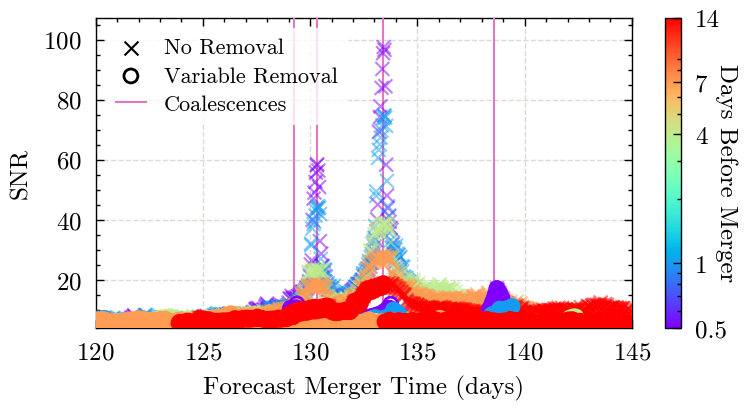

In [5]:
fig_focused_predict, _ = plotting_utils.plot_around_time(
    results_one=results_noremoval,
    results_two=results_varremoval,
    truth_times=truth_times_s,
    times_before=times_before,
    label_one='No Removal',
    label_two='Variable Removal',
    alpha_one=0.5,
    start_time_offset=120,
    end_time_offset=145,
    width_factor=1.25
)


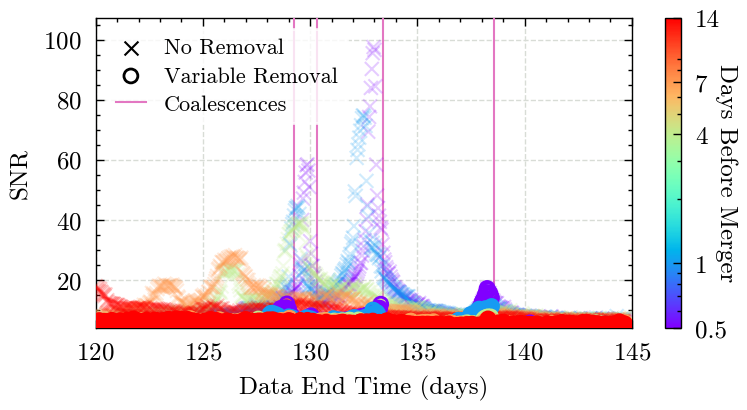

In [6]:
fig_focused_dataend, _ = plotting_utils.plot_around_time(
    results_one=results_noremoval,
    results_two=results_varremoval,
    truth_times=truth_times_s,
    times_before=times_before,
    label_one='No Removal',
    label_two='Variable Removal',
    alpha_one=0.2,
    start_time_offset=120,
    end_time_offset=145,
    width_factor=1.25,
    predicted_time=False
)

## No Removal - predicted time, with upper limit to plot:

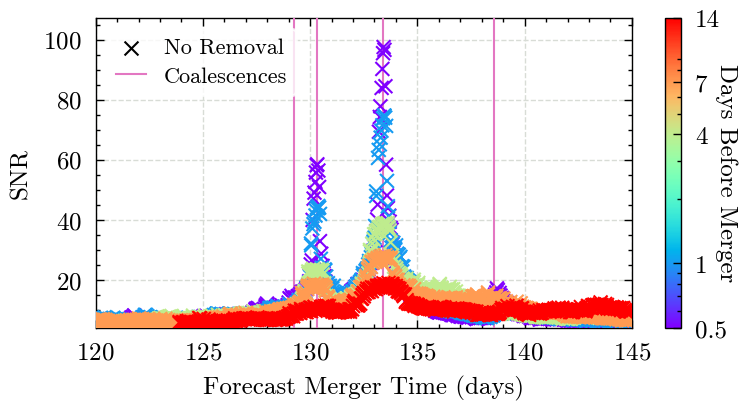

In [7]:
fig_focused_predict, ax_focused_predict = plotting_utils.plot_around_time(
    results_one=results_noremoval,
    truth_times=truth_times_s,
    times_before=times_before,
    label_one='No Removal',
    start_time_offset=120,
    end_time_offset=145,
    width_factor=1.25,
)

## Variable removal - predicted time

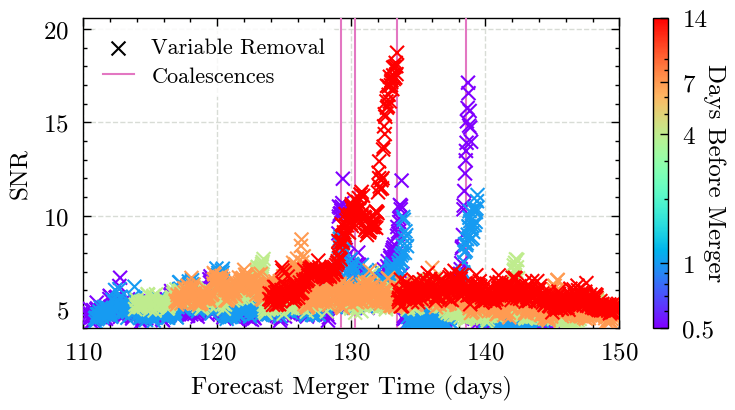

In [8]:
fig_focused_var_predicted, _ = plotting_utils.plot_around_time(
    results_one=results_varremoval,
    truth_times=truth_times_s,
    times_before=times_before,
    label_one='Variable Removal',
    start_time_offset=110,
    end_time_offset=150,
    width_factor=1.25
)

## Variable removal - end time 

A better, labelled, version of this is made later to appear in the paper - that one uses filtered times-before-merger so is a bit clearer

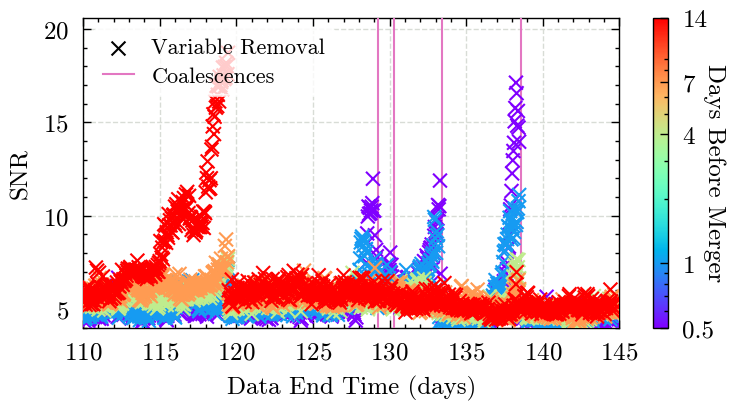

In [9]:
fig_focused_var_end_time, _ = plotting_utils.plot_around_time(
    results_one=results_varremoval,
    truth_times=truth_times_s,
    times_before=times_before,
    label_one='Variable Removal',
    predicted_time=False,
    start_time_offset=110,
    end_time_offset=145,
    width_factor=1.25
)

## No removal - predicted time

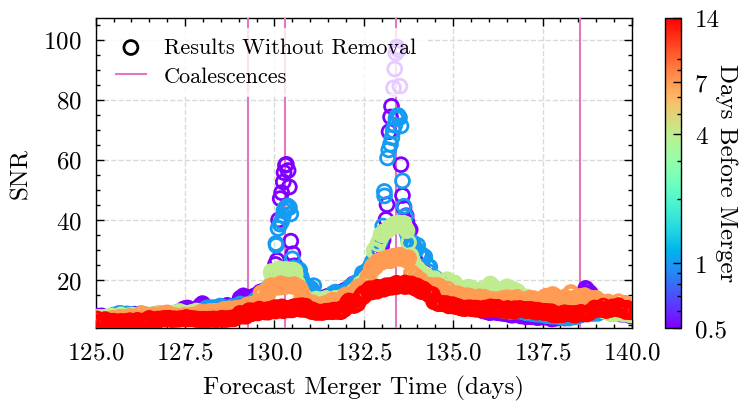

In [10]:
fig_focused_no_predicted, _ = plotting_utils.plot_around_time(
    results_one=results_noremoval,
    times_before=times_before,
    truth_times=truth_times_s,
    label_one='Results Without Removal',
    marker_one='o',
    start_time_offset=125,
    end_time_offset=140,
    width_factor=1.25
)

## No removal - data end time

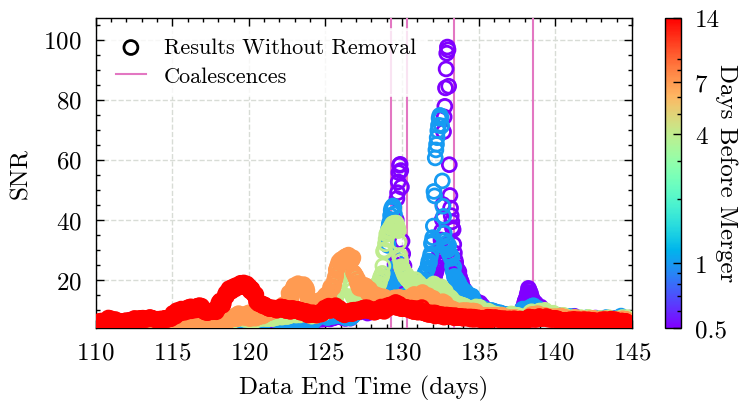

In [11]:
fig_focused_no_dataend, _ = plotting_utils.plot_around_time(
    results_one=results_noremoval,
    times_before=times_before,
    truth_times=truth_times_s,
    label_one='Results Without Removal',
    predicted_time=False,
    marker_one='o',
    start_time_offset=110,
    end_time_offset=145,
    width_factor=1.25
)

## Removal 2 hours before merger - predicted time

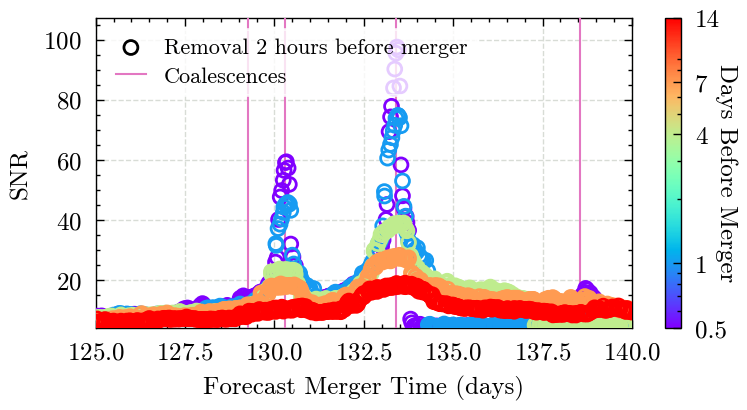

In [12]:
fig_focused_2hr_predicted, _ = plotting_utils.plot_around_time(
    results_one=results_2hrremoval,
    times_before=times_before,
    truth_times=truth_times_s,
    label_one='Removal 2 hours before merger',
    marker_one='o',
    start_time_offset=125,
    end_time_offset=140,
    width_factor=1.25
)

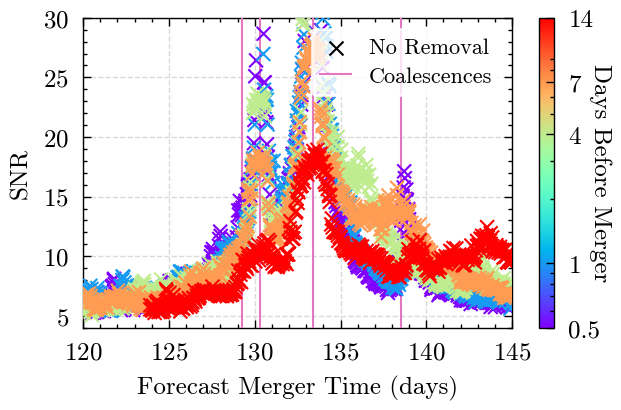

In [13]:
fig_focused_predict, ax_focused_predict = plotting_utils.plot_around_time(
    results_one=results_noremoval,
    truth_times=truth_times_s,
    times_before=times_before,
    label_one='No Removal',
    start_time_offset=120,
    end_time_offset=145,
    legend_loc='upper right'
)

ax_focused_predict[0].set_ylim(top=30)

fig_focused_predict.savefig(f'{paper_plots_dir}/figure_9a_focused_region_no_removal.png')


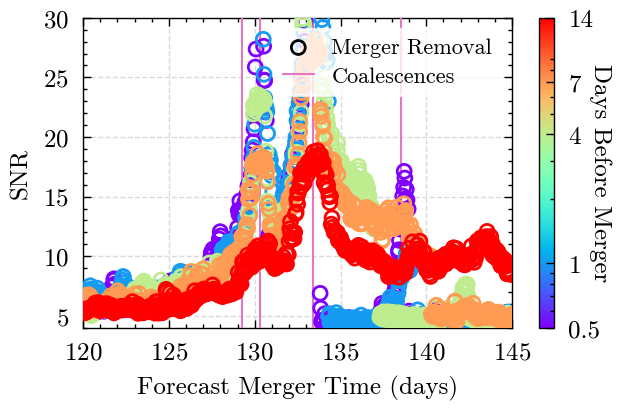

In [14]:
fig_focused_predict, ax_focused_predict = plotting_utils.plot_around_time(
    results_one=results_2hrremoval,
    truth_times=truth_times_s,
    times_before=times_before,
    label_one='Merger Removal',
    marker_one='o',
    legend_loc='upper right',
    start_time_offset=120,
    end_time_offset=145,
)

ax_focused_predict[0].set_ylim(top=30)

fig_focused_predict.savefig(f'{paper_plots_dir}/figure_9b_focused_region_2hr_removal.png')

## Removal 2 hours before merger - data end time

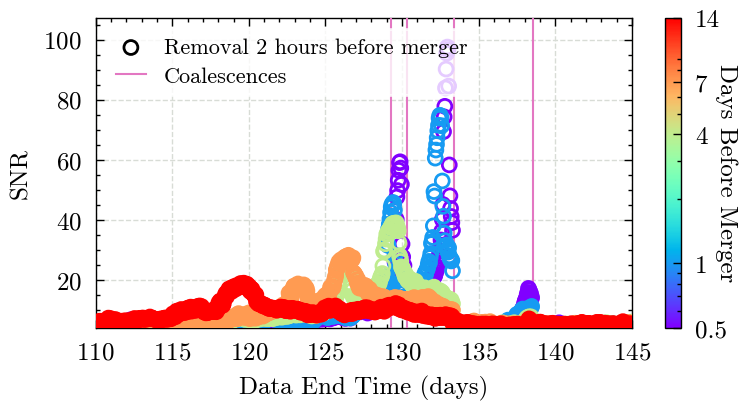

In [15]:
fig_focused_2hr_dataend, _ = plotting_utils.plot_around_time(
    results_one=results_2hrremoval,
    times_before=times_before,
    truth_times=truth_times_s,
    label_one='Removal 2 hours before merger',
    predicted_time=False,
    marker_one='o',
    start_time_offset=110,
    end_time_offset=145,
    width_factor=1.25
)

# The focused region section main plot - variable removal end times, with labels

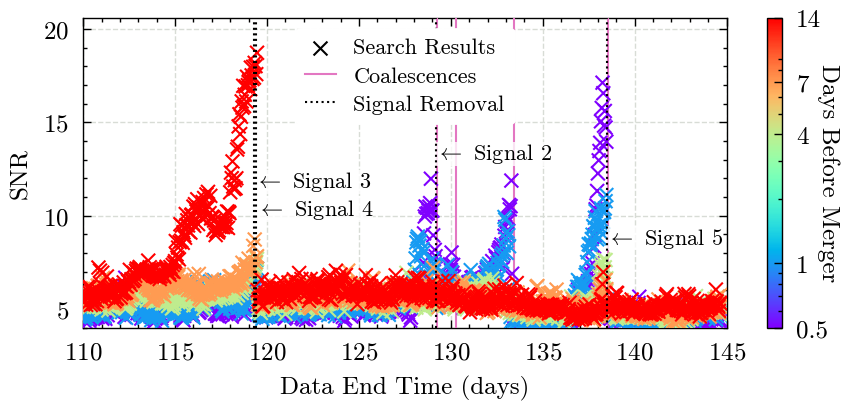

In [ ]:
fig_focused_dataend, (ax_focused_dataend, labels, lines) = plotting_utils.plot_around_time(
    results_one=results_varremoval,
    times_before=times_before,
    truth_times=truth_times_s,
    label_one='Search Results',
    predicted_time=False,
    start_time_offset=110,
    end_time_offset=145,
    width_factor=1.5
)
# Add lines for when the signals are removed from the data
lines.append(ax_focused_dataend.axvline(
    0,
    c='k',
    linestyle=':'
))
labels.append('Signal Removal')
# ax_focused_dataend.legend(loc='upper left')
for signal_number, time_before in zip(signals_in_region, removal_time_s):
    ax_focused_dataend.axvline(
        (truth_times_s[signal_number] - time_before) / 86400,
        c='k',
        linestyle=':',
        zorder=100
    )
    ax_focused_dataend.text(
        (truth_times_s[signal_number] - time_before + 1800) / 86400,
        16-signal_number*1.5,
        f'$\leftarrow$ Signal {signal_number}', 
        fontsize=8,
        zorder=40,
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none',boxstyle='square,pad=0')
    )
leg = ax_focused_dataend.legend(
    handles=lines,
    labels=labels,
    loc='upper center',
    framealpha=1,
    frameon=True,
)
leg.set_zorder(150)
fig_focused_dataend.savefig(f'{paper_plots_dir}/figure_10_focused_region_variable_removal.png')

## Make a table of removed times (days) to be added to the paper

In [ ]:
table_str = """\\begin{tabular}{|cc|cc|}
\\hline
\\multicolumn{2}{|c|}{Signal} & \\multicolumn{2}{c|}{Removal Time} \\\\
\\hline
Number & Time (days) & Offset & Time (days) \\\\
\\hline
"""
for signal_number, time_before in zip(signals_in_region, removal_time_s):
    if time_before > 86400:
        removal_time_str = f"{time_before / 86400:.0f} days"
    else:
        removal_time_str = f"{time_before / 3600:.0f} hours"
    truth_time_days = truth_times_s[signal_number] / 86400
    table_str += f"{signal_number} & {truth_time_days:.1f} & {removal_time_str} & {truth_time_days - time_before/86400:.1f} \\\\\n"
table_str += """\\hline
\\end{tabular}
"""

print(table_str)
with open('../../paper/tables/table_4_focused_removal_times.tex', 'w') as frt_table:
    frt_table.write(table_str)


\begin{tabular}{|cc|cc|}
\hline
\multicolumn{2}{|c|}{Signal} & \multicolumn{2}{c|}{Removal Time} \\
\hline
Number & Time (days) & Offset & Time (days) \\
\hline
2 & 129.3 & 2 hours & 129.2 \\
3 & 130.3 & 11 days & 119.3 \\
4 & 133.4 & 14 days & 119.4 \\
5 & 138.6 & 2 hours & 138.5 \\
\hline
\end{tabular}



Now make some statements about the relative times when a signal is removed, e.g. signal N is removed x days before/after signal M merges

In [18]:

for signal_number_1, time_before_1 in zip(signals_in_region, removal_time_s):
    for signal_number_2, time_before_2 in zip(signals_in_region, removal_time_s):
        offset_merger = (truth_times_s[signal_number_2]) - (truth_times_s[signal_number_1] - time_before_1)
        if offset_merger < 0:
            offset_merger_removed_str = f'{-offset_merger / 86400:.2f} days after'
        else:
            offset_merger_removed_str = f'{offset_merger / 86400:.2f} days before'
        print(f"Signal {signal_number_1} is removed {offset_merger_removed_str} signal {signal_number_2} merges")
        if signal_number_1 >= signal_number_2: continue
        offset = (truth_times_s[signal_number_2] - time_before_2) - (truth_times_s[signal_number_1] - time_before_1)
        if offset < 0:
            offset_removed_str = f'{-offset / 86400:.2f} days after'
        else:
            offset_removed_str = f'{offset / 86400:.2f} days before'
        print(f"Signal {signal_number_1} is removed {offset_removed_str} signal {signal_number_2} is removed")


Signal 2 is removed 0.08 days before signal 2 merges
Signal 2 is removed 1.13 days before signal 3 merges
Signal 2 is removed 9.87 days after signal 3 is removed
Signal 2 is removed 4.24 days before signal 4 merges
Signal 2 is removed 9.76 days after signal 4 is removed
Signal 2 is removed 9.38 days before signal 5 merges
Signal 2 is removed 9.30 days before signal 5 is removed
Signal 3 is removed 9.95 days before signal 2 merges
Signal 3 is removed 11.00 days before signal 3 merges
Signal 3 is removed 14.11 days before signal 4 merges
Signal 3 is removed 0.11 days before signal 4 is removed
Signal 3 is removed 19.25 days before signal 5 merges
Signal 3 is removed 19.16 days before signal 5 is removed
Signal 4 is removed 9.84 days before signal 2 merges
Signal 4 is removed 10.89 days before signal 3 merges
Signal 4 is removed 14.00 days before signal 4 merges
Signal 4 is removed 19.14 days before signal 5 merges
Signal 4 is removed 19.06 days before signal 5 is removed
Signal 5 is remo